# Dump 1 noise-pulse survey — series 07221203_2025

**Series:** `07221203_2025` (R76, Run76 log)
**Dump:** `F0001` ("dump 1")
**Run log context** (from `R76/DataSeriesList.xlsx`, `Run76` sheet):

| field | value |
|---|---|
| type | Side2 |
| source / shield | PuBe / Pb&poly, lead stack, borax |
| HV | -83.2 V |
| trigger | DCRC1pA 2 |
| source position | Position 3 |
| duration | 30 min |
| notes | low-trigger threshold data |

This is the only R76-tagged series already present locally under `~/idx/` (the other two
local dumps, `07180808_1558_F0009` and `07180827_0000_F00xx`, are tagged `R68` in the
nsdf-cli manifest) — if you meant a different series, swap the path in the cell below.

**Goal:** set up a first pass at picking out "good" noise pulses — individual channel traces
that look like pure stationary baseline noise, with no real physics pulse riding on top —
as a starting point for a noise PSD study. There's no dedicated "Randoms" trigger in this
dump (only `Physics` and `Unknown`), so the cut below is data-driven: it compares each
trace's full-length excursion to its own pretrigger baseline scatter, rather than relying
on a trigger-type flag.

Run this notebook with the `darkmatter_cli_env` conda environment (same as
`R76Noise.ipynb` / `NSDF_noise.ipynb`) so `nsdf_dark_matter` and `openvisusnogui` are available.

In [1]:
from nsdf_dark_matter.idx import load_all_data
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

home_directory = Path.home()
series_path = str(home_directory) + '/idx/07221203_2025_F0001'
print("loading:", series_path)

cdms = load_all_data(series_path)

loading: /Users/villaa/idx/07221203_2025_F0001


In [2]:
event_ids = cdms.get_event_ids()
detector_ids = cdms.get_detector_ids()

print(f"events: {len(event_ids)}")
print(f"channel groups (detector_ids): {len(detector_ids)}")
print("sample detector id:", detector_ids[0])

sample_meta = cdms.get_event_metadata(event_ids[0])
print("sample event metadata:", sample_meta.trigger_type, sample_meta.readout_type, sample_meta.global_timestamp)

events: 1570
channel groups (detector_ids): 4551
sample detector id: 10000_0_Phonon_4096
sample event metadata: Physics None Sunday, December 04, 2022 02:25:47 AM UTC


In [3]:
from collections import Counter

trigger_counts = Counter(cdms.get_event_metadata(e).trigger_type for e in event_ids)
print("trigger type counts:", trigger_counts)

trigger type counts: Counter({'Physics': 1008, 'Unknown': 562})


## Per-trace baseline stats

Each `detector_id` (an `<event>_<group>_Phonon_4096` entry) returns 4 channel traces of
4096 ADC samples (uint16). For every individual channel trace we compute:

- `bmean`, `bstd` — mean and std of a pretrigger window (first 1000 samples)
- `dev` — the largest deviation from `bmean`, measured only in the **post-pretrigger**
  region (samples 1000-4096). Measuring it over the *whole* trace (including the very
  samples used to compute `bstd`) was the bug in the first version of this notebook: the
  max of ~1000 baseline samples is, by basic extreme-value statistics, already 3-4x their
  own std, which puts a hard floor around `ratio ~ 1` even for pure noise — no threshold
  below that (e.g. 0.5) can ever select anything. Restricting `dev` to the region *after*
  the baseline window removes that artificial floor.
- `ratio = dev / bstd` — how many "pretrigger sigma" the biggest post-baseline excursion
  reaches.

Channels with `bstd == 0` are excluded up front — a perfectly flat pretrigger window means
the channel is dead/unread for that trace, not quiet noise. `bstd` itself can also be
*inflated* (early pileup, drift, RF pickup during the baseline window) — a clearly-pulsed
trace can still pass a `ratio` cut if its own baseline was already noisy, which is why the
selection below adds a second, absolute cap on `bstd` in addition to the ratio.

In [4]:
PRETRIGGER_SAMPLES = 1000

records = []  # (detector_id, channel_index, bmean, bstd, dev)
for d in detector_ids:
    channels = cdms.get_detector_channels(d)
    for c in range(channels.shape[0]):
        trace = channels[c].astype(np.float64)
        base = trace[:PRETRIGGER_SAMPLES]
        bmean, bstd = base.mean(), base.std()
        post = trace[PRETRIGGER_SAMPLES:]
        dev = np.max(np.abs(post - bmean))
        records.append((d, c, bmean, bstd, dev))

detector_id_arr = np.array([r[0] for r in records])
channel_arr = np.array([r[1] for r in records])
bmean_arr = np.array([r[2] for r in records])
bstd_arr = np.array([r[3] for r in records])
dev_arr = np.array([r[4] for r in records])

active = bstd_arr > 0
ratio_arr = np.full_like(bstd_arr, np.inf)
ratio_arr[active] = dev_arr[active] / bstd_arr[active]

print(f"total channel traces: {len(records)}")
print(f"active (nonzero pretrigger std): {active.sum()} ({100*active.sum()/len(records):.1f}%)")
print("bstd percentiles (active):", np.percentile(bstd_arr[active], [50, 75, 90, 95, 99]))

total channel traces: 18204
active (nonzero pretrigger std): 10619 (58.3%)
bstd percentiles (active): [  2.72420979  33.17634713 211.98500704 302.69767505 452.56755595]


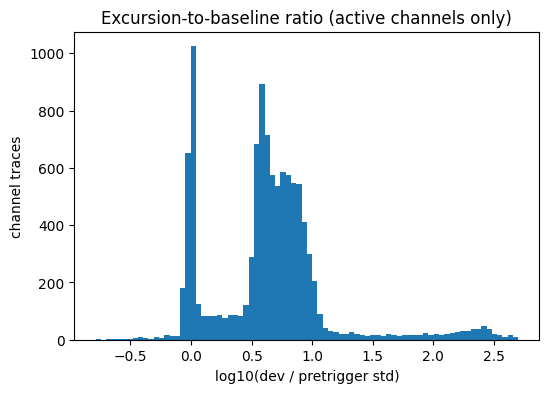

ratio percentiles (active only):
  p10: 1.00
  p25: 2.45
  p50: 4.39
  p75: 6.99
  p90: 10.14
  p95: 44.69
  p99: 279.35


In [5]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(np.log10(ratio_arr[active]), bins=80)
ax.set_xlabel("log10(dev / pretrigger std)")
ax.set_ylabel("channel traces")
ax.set_title("Excursion-to-baseline ratio (active channels only)")
plt.show()

print("ratio percentiles (active only):")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p}: {np.percentile(ratio_arr[active], p):.2f}")

## "Good noise" selection

Two-part cut, both required:

- **`bstd < BASELINE_STD_CAP`** — the pretrigger window itself has to look quiet in
  absolute terms. This is what catches traces where an inflated baseline (early pileup,
  drift) let a real pulse hide under a loose ratio cut.
- **`ratio < GOOD_RATIO_THRESH`** — no post-baseline excursion exceeds `GOOD_RATIO_THRESH`
  times the pretrigger scatter.

`BASELINE_STD_CAP = 5` sits just above the 50th-percentile `bstd` for active channels
(the distribution is bimodal: quiet channels cluster near 2-3 ADC counts, contaminated
ones jump to 30+), and `GOOD_RATIO_THRESH = 5` is a first-pass value on the corrected
(post-baseline-only) ratio. Tighten either for a purer sample, loosen for more statistics.
A single-number threshold like 0.5 on `ratio` alone isn't reachable — see the note in the
previous cell — but `BASELINE_STD_CAP` gives you the strict/loose knob that number was
really after.

In [ ]:
BASELINE_STD_CAP = 5
GOOD_RATIO_THRESH = 2.45  # p25 of the post-baseline ratio distribution — a tight cut

good_mask = active & (bstd_arr < BASELINE_STD_CAP) & (ratio_arr < GOOD_RATIO_THRESH)
n_good = good_mask.sum()

print(f"good noise traces: {n_good} / {len(records)} "
      f"({100*n_good/len(records):.1f}% of all, {100*n_good/active.sum():.1f}% of active)")

good_detector_ids = detector_id_arr[good_mask]
good_channels = channel_arr[good_mask]

### Table of passing traces

At this tight threshold there are few enough survivors to list in full — one row per
(event, channel group, channel).

In [ ]:
from IPython.display import display, HTML
import csv

good_idx_all = np.where(good_mask)[0]

rows = []
for i in good_idx_all:
    detector_id = detector_id_arr[i]
    event_id, group, *_ = detector_id.split('_')
    rows.append({
        "event": event_id,
        "group": int(group),
        "channel": int(channel_arr[i]),
        "bstd": round(float(bstd_arr[i]), 3),
        "dev": round(float(dev_arr[i]), 3),
        "ratio": round(float(ratio_arr[i]), 3),
    })

rows.sort(key=lambda r: (int(r["event"]), r["group"], r["channel"]))

html = ["<table><tr>" + "".join(f"<th>{k}</th>" for k in rows[0].keys()) + "</tr>"]
for r in rows:
    html.append("<tr>" + "".join(f"<td>{v}</td>" for v in r.values()) + "</tr>")
html.append("</table>")
display(HTML("".join(html)))

csv_path = "good_noise_traces.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print(f"\nsaved {len(rows)} rows to {csv_path}")

## Visual check: good noise traces vs. rejected (pulse-like) traces

In [ ]:
CHANNEL_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # ch0..ch3

rng = np.random.default_rng(0)
n_show = 6

good_groups = np.unique(detector_id_arr[good_mask])
show_groups = rng.choice(good_groups, size=min(n_show, len(good_groups)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, d in zip(axes.flat, show_groups):
    channels = cdms.get_detector_channels(d)
    for c in range(channels.shape[0]):
        trace = channels[c].astype(np.float64)
        trace -= trace[:PRETRIGGER_SAMPLES].mean()
        passed = np.any((detector_id_arr == d) & (channel_arr == c) & good_mask)
        ax.plot(trace, linewidth=0.8, color=CHANNEL_COLORS[c],
                label=f"ch{c}" + (" *" if passed else ""))
    ax.set_title(d, fontsize=9)
    ax.legend(fontsize=7, loc="upper right")
fig.suptitle("Sample of 'good' groups — all 4 channels overlaid (* = passed the cut)")
fig.tight_layout()
plt.show()

In [ ]:
rejected_mask = active & ~good_mask
rejected_groups = np.unique(detector_id_arr[rejected_mask])
show_rej_groups = rng.choice(rejected_groups, size=min(n_show, len(rejected_groups)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, d in zip(axes.flat, show_rej_groups):
    channels = cdms.get_detector_channels(d)
    for c in range(channels.shape[0]):
        trace = channels[c].astype(np.float64)
        trace -= trace[:PRETRIGGER_SAMPLES].mean()
        passed = np.any((detector_id_arr == d) & (channel_arr == c) & good_mask)
        ax.plot(trace, linewidth=0.8, color=CHANNEL_COLORS[c],
                label=f"ch{c}" + (" *" if passed else ""))
    ax.set_title(d, fontsize=9)
    ax.legend(fontsize=7, loc="upper right")
fig.suptitle("Sample of rejected groups — all 4 channels overlaid (* = passed the cut)")
fig.tight_layout()
plt.show()

## Next steps

- Eyeball the two grids above — tune `GOOD_RATIO_THRESH` until "good" really looks flat
  and "rejected" really looks pulse-like, then re-run.
- Save `good_detector_ids` / `good_channels` (e.g. to a `.npy` or `.csv` in
  `analysis_notes/`) so downstream notebooks don't have to redo this selection.
- Once a stable "good noise" sample exists, compute an average noise PSD from it
  (`np.fft.rfft` per trace, average `|FFT|^2`) as the actual deliverable of this study.
- Cross-check flagged-bad series from the run log's `notes` column (e.g. Run76's
  `07220426_1120` was noted "noise outlier") against this trace-level cut to sanity-check
  the threshold against what the experimenters already flagged by hand.